<a href="https://www.mbd.rwth-aachen.de/">
    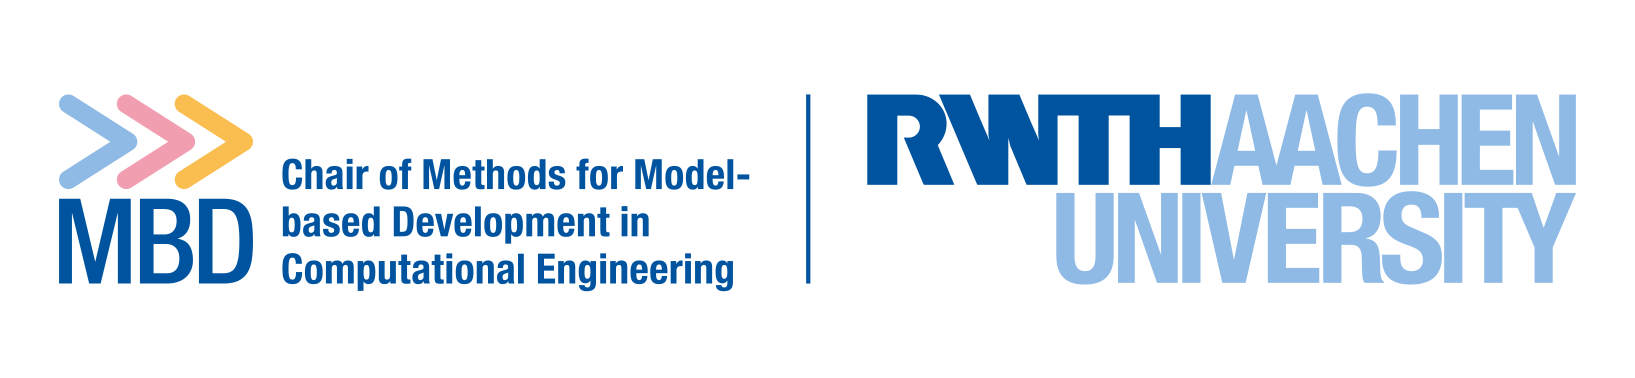
</a>
<a href="https://www.cpbl.rwth-aachen.de/">
    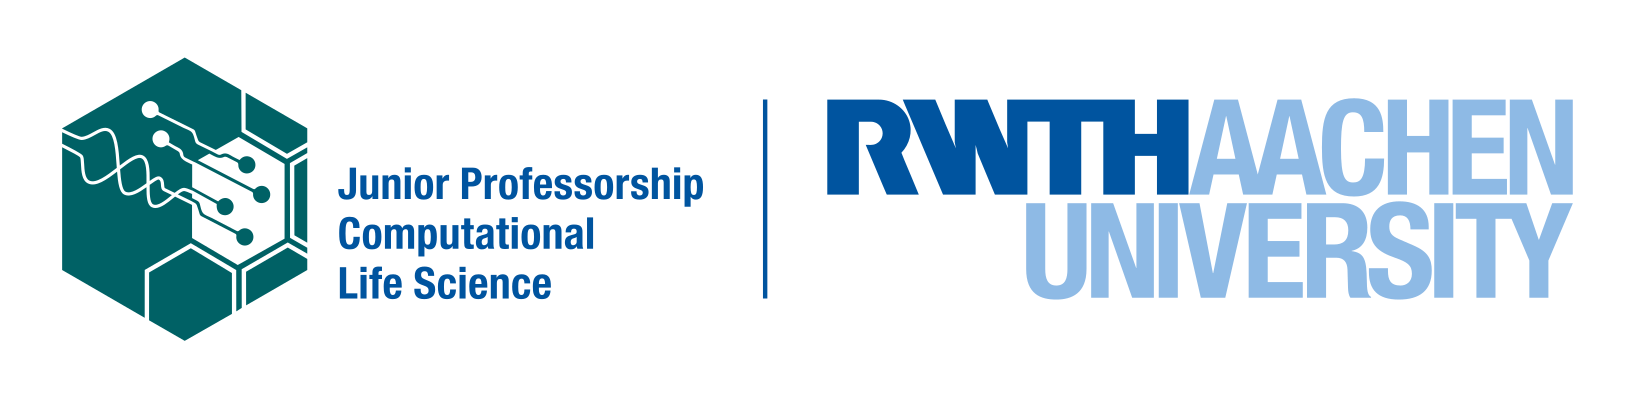
</a>

# **Societal Challenges Datathon**

Name: **Yajesh Chandra**

Student number (Matrikelnummer): **FILL-ME**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
variables_df = pd.read_csv('data/extra/variables.csv')

def desc(variable_name):

    is_missing = variable_name.endswith('_missing')

    base_var = variable_name.replace('_missing', '') if is_missing else variable_name

    row = variables_df[variables_df['Variable Name'] == base_var]

    if row.empty:
        return {
            'renamed': variable_name,
            'description': 'Variable not in variables.csv',
            'data_file': None,
            'file_description': 'Derived_variable'
        }

    row = row.iloc[0]

    renamed = row['Renamed_variables']
    if is_missing:
        renamed = f"{renamed}_missing"

    return {
        'renamed': renamed,
        'description': row['Variable Description'],
        'data_file': row['Data File Name'],
        'file_description': row['Data File Description']
    }

    
def load_all_xpt_files(folder='data/raw/',blacklist=[]):

    datasets = {}
    
    for file in os.listdir(folder):
        if file.endswith('.XPT') and file not in blacklist:
            try:
                # Read the XPT file
                data = pd.read_sas(os.path.join(folder, file), format='xport', encoding='utf-8')
                
                # Strip whitespace from column names
                data.columns = [col.strip() for col in data.columns]
                
                # Use filename without extension as key
                file_key = file.replace('.XPT', '').lower()
                datasets[file_key] = data
                
                
                print(f"Loaded: {file} - Shape: {data.shape}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
    
    return datasets

In [4]:
print("Loading all .XPT files from data/raw/...")

blacklist = ['acculturation.XPT',
'alcohol_use.XPT',
'current_health_status.XPT',
'dermatology.XPT',
'diet_behavior_nutrition.XPT',
'health_insurance.XPT',
'housing_characteristics.XPT',
'immunization.XPT',
'income.XPT',
'pesticide_use.XPT',
'physical_activity.XPT',
'physical_activity_youth.XPT',
'prescription_medications.XPT',
'hepatitis.XPT',
"early_childhood.XPT",
"occupation.XPT",
"preventive_aspirin_use.XPT",
"smoking_household_smokers.XPT",
"smoking_recent_tobacco_use.XPT",
"sleep_disorders.XPT"] # Add any filenames (without .XPT) to exclude here if needed

all_data = load_all_xpt_files('data/raw/', blacklist=blacklist)



Loading all .XPT files from data/raw/...
Loaded: audiometry.XPT - Shape: (11744, 14)
Loaded: blood_pressure_cholesterol.XPT - Shape: (8501, 6)
Loaded: diabetes.XPT - Shape: (11744, 9)
Loaded: functioning.XPT - Shape: (10942, 32)
Loaded: hospital_utilization_access_to_care.XPT - Shape: (11933, 6)
Loaded: kidney_condition_urology.XPT - Shape: (7809, 9)
Loaded: medical_conditions.XPT - Shape: (11744, 35)
Loaded: mental_health_depression_screener.XPT - Shape: (6337, 11)
Loaded: oral_health.XPT - Shape: (11744, 8)
Loaded: smoking_cigarette_use.XPT - Shape: (9015, 9)
Loaded: weight_history.XPT - Shape: (8501, 5)


In [5]:
cardiovascular_cluster = [
    'EverTold_Hypertension',
    'EverTold_HighCholesterol',
    'EverTold_TakeAspirin',
    'CurrentlyTaking_CholesterolMedication',
    'CurrentlyTaking_BloodPressureMedication',
]

functional_assessment_cluster = [
    'DifficultyWalkingClimbingSteps_Level',
    'DifficultyUsingHandsFingers_Level',
    'DifficultySeeingWithGlasses_Level',
    'DifficultyLiftingWeight_Level',
    'DifficultySelfCare_Level',
    'DifficultyRememberingConcentrating_Level',
    'DifficultyWalkingComparedToPeers_Level',
    'AdultDisabilityIndicator',
    'AdultEnhancedDisabilityIndicator',
]

urinary_health_cluster = [
    'UrineLeakageFrequency',
    'NightUrinationFrequency_30Days',
    'LeakageWithUrgency_12Months',
    'ImpactOfLeakageOnLife_12Months',
    'UrineLeakageAmount',
]


oral_health_cluster = [
    'OverallHealth_TeethAndGums',
    'MouthPain_Frequency_LastYear',
    'DiscomfortEating_TeethIssues',
    'LifeSatisfaction_Impact_TeethIssues',
    'AvoidedFoods_TeethIssues',
    'SelfConscious_TeethIssues',
]


sensory_function_cluster = [
    'DifficultySeeingWithGlasses_Level',
    'HearingStatus_NoAid',
    'DifficultyHearing_WithBackgroundNoise',
    'DifficultyHearingWithAid_Level',
]


mental_health_cluster = [
    'FatigueFrequency_2weeks',
    'SleepProblemsFrequency_2weeks',
    'AppetiteChangesFrequency_2weeks',
    'DifficultyMakingFriends_Level',
]


smoking_history_cluster = [
    'SmokedAtLeast100CigarettesInLife',
    'CurrentCigaretteSmoking',
    'FirstCigaretteAge',
    'NumberOfDaysSmokedPipe_5Days',
]


general_medical_history_cluster = [
    'EverTold_Arthritis',
    'EverTold_Cancer',
    'AnemiaTreatment_Last3Months',
    'EverHad_GallbladderSurgery',
    'BloodSugarTest_Last3Years',
    'OverweightDiagnosis',
    'PeriodStarted',
]

all_clusters = cardiovascular_cluster + \
    functional_assessment_cluster + \
    urinary_health_cluster + \
    oral_health_cluster + \
    sensory_function_cluster + \
    mental_health_cluster + \
    smoking_history_cluster + \
    general_medical_history_cluster
    


top50 = [
    'GeneralHealth_Status',
    'EverTold_Hypertension',
    'DifficultyWalkingClimbingSteps_Level',
    'CurrentlyTaking_CholesterolMedication',
    'OverallHealth_TeethAndGums',
    'EverTold_HighCholesterol',
    'DifficultyUsingHandsFingers_Level',
    'EverTold_TakeAspirin',
    'AdultDisabilityIndicator',
    'WorkExperience_LastWeek',
    'AdultEnhancedDisabilityIndicator',
    'UrineLeakageFrequency',
    'EverTold_Arthritis',
    'WeightAssessment',
    'NightUrinationFrequency_30Days',
    'QuestionnaireModeFlag',
    'LeakageWithUrgency_12Months',
    'OverweightDiagnosis',
    'ImpactOfLeakageOnLife_12Months',
    'DifficultySeeingWithGlasses_Level',
    'BloodSugarTest_Last3Years',
    'HearingStatus_NoAid',
    'FirstCigaretteAge',
    'DifficultyHearing_WithBackgroundNoise',
    'CurrentlyTaking_BloodPressureMedication',
    'NumberOfDaysSmokedPipe_5Days',
    'DifficultyLiftingWeight_Level',
    'RatioEnglishSpanishAtHome',
    'LifeSatisfaction_Impact_TeethIssues',
    'DiscomfortEating_TeethIssues',
    'DifficultySelfCare_Level',
    'UrineLeakageAmount',
    'UsesSunscreenFrequency',
    'DifficultyRememberingConcentrating_Level',
    'AvoidedFoods_TeethIssues',
    'TelehealthAppointment_Past12Months',
    'EverHad_GallbladderSurgery',
    'MouthPain_Frequency_LastYear',
    'PeriodStarted',
    'FatigueFrequency_2weeks',
    'SleepProblemsFrequency_2weeks',
    'EverTold_Cancer',
    'DifficultyMakingFriends_Level',
    'SmokedAtLeast100CigarettesInLife',
    'DifficultyHearingWithAid_Level',
    'DifficultyWalkingComparedToPeers_Level',
    'AnemiaTreatment_Last3Months',
    'SelfConscious_TeethIssues',
    'CurrentCigaretteSmoking',
    'AppetiteChangesFrequency_2weeks',
]

In [6]:
for df_name, df in all_data.items():
    print(f"Columns in {df_name}:")
    for col in sorted(df.columns.tolist()):
        # print(col)
        col_info = desc(col)
        col_renamed = col_info['renamed']
        if col_renamed in all_clusters:
            print(f"  - {col} (renamed: {col_renamed}) <-- in cluster")
        elif col_renamed in top50:
            print(f"  - {col} (renamed: {col_renamed}) <-- in top50")
        else:
            print(f"  - {col} (renamed: {col_renamed})")
        
    print("\n\n")

Columns in audiometry:
  - AUQ054 (renamed: HearingStatus_NoAid) <-- in cluster
  - AUQ101 (renamed: DifficultyHearing_WithBackgroundNoise) <-- in cluster
  - AUQ144 (renamed: LastHearingTest_Specialist)
  - AUQ410A (renamed: reason_hearing_loss_A)
  - AUQ410B (renamed: reason_hearing_loss_B)
  - AUQ410C (renamed: reason_hearing_loss_C)
  - AUQ410D (renamed: reason_hearing_loss_D)
  - AUQ410E (renamed: reason_hearing_loss_E)
  - AUQ410F (renamed: reason_hearing_loss_F)
  - AUQ410G (renamed: reason_hearing_loss_G)
  - AUQ410H (renamed: reason_hearing_loss_H)
  - AUQ410I (renamed: reason_hearing_loss_I)
  - AUQ410J (renamed: reason_hearing_loss_J)
  - SEQN (renamed: sequence_no)



Columns in blood_pressure_cholesterol:
  - BPQ020 (renamed: EverTold_Hypertension) <-- in cluster
  - BPQ030 (renamed: ConfirmedHypertension_Visits)
  - BPQ080 (renamed: EverTold_HighCholesterol) <-- in cluster
  - BPQ101D (renamed: CurrentlyTaking_CholesterolMedication) <-- in cluster
  - BPQ150 (renamed: Cur

## **Column Selection and Cleaning**



In [7]:
def clean(df, columns_to_drop,masking = False, drop_high_missing=False,display_drop_info=True, median_impute=list(),handling_range=[30,50]):
    df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
    
    for col in df_cleaned.columns:
        if col == 'SEQN':
            continue 

        max_value = df_cleaned[col].max()
        # if max_value is of form 9, 99 , 999 , 9999 etc, consider it as valid else not
        if not str(int(max_value)).lstrip('-').rstrip('0').rstrip('.').isdigit() or not all(c == '9' for c in str(int(max_value)).lstrip('-').rstrip('0').rstrip('.')):
            continue
        else:
            second_largest = 7 * max_value / 9
            top2 = [max_value, second_largest]
            df_cleaned.loc[df_cleaned[col].isin(top2), col] = np.nan

        missing_percentage = df_cleaned[col].isnull().mean() * 100

    
        if missing_percentage <= handling_range[0]:
            if col in median_impute:
                df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())  
            else:
                df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

        elif handling_range[0] < missing_percentage <= handling_range[1]:
            if masking:
                df_cleaned[f'{col}_missing'] = df_cleaned[col].isnull().astype(int)
                if col in median_impute:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())  
                else:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
            elif missing_percentage <handling_range[0]+5:
                if col in median_impute:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())  
                else:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
        elif missing_percentage > 50:
            if drop_high_missing:
                df_cleaned.drop(columns=[col], inplace=True)
                if display_drop_info:
                    print(f"Dropped column {col} due to high missing percentage: {missing_percentage:.2f}%")
            elif display_drop_info:
                print(f"[SKIPED] Too many missing values in column {col} - missing percentage: {missing_percentage:.2f}%")
            if display_drop_info :
                print(f"{desc(col)['renamed']} - {desc(col)['description']}")
                print('\n')
                print('\n')
            continue 

        missing_percentage_new = df_cleaned[col].isnull().mean() * 100

        desc_info = desc(col)
        print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
        print(f"  - Range: {df_cleaned[col].min()} to {df_cleaned[col].max()}")
        print(f"No of Unique Values: {df_cleaned[col].nunique()}")
        print(f"  - Unique Values Frequency:\n{df_cleaned[col].value_counts()}\n")
        print(f"Shape after cleaning: {df_cleaned.shape}")
        print(f"Missing Percentage change: {round(missing_percentage,2)}% -> {round(missing_percentage_new, 2)}%\n")
        print('\n')
        print('\n')

    return df_cleaned

cleaned_all_data = {}


In [8]:
# diabetes = all_data.get('diabetes', pd.DataFrame()).copy()

# #delete diabetes table from all data

# # Keep required columns
# diabetes = diabetes[['SEQN', 'DIQ010', 'DIQ160']]
# # print(diabetes.value_counts())
# all_data.pop('diabetes', None)

# # Create target column
# diabetes['diabetes_class'] = 0  # default = No diabetes

# # Diabetes
# diabetes.loc[
#     diabetes['DIQ010'] == 1,
#     'diabetes_class'
# ] = 1

# # Prediabetes == Diabetes
# # diabetes.loc[
# #     (diabetes['DIQ010'] == 3) |
# #     ((diabetes['DIQ010'] == 2) & (diabetes['DIQ160'] == 1)),
# #     'diabetes_class'
# # ] = 1

# # Keep only what you need
# target_variable = diabetes[['SEQN', 'diabetes_class']].dropna()

# print(target_variable.head())
# print(target_variable['diabetes_class'].value_counts())
diabetes = all_data.get('diabetes', pd.DataFrame()).copy()
all_data.pop('diabetes', None)

# Keep required columns
diabetes = diabetes[['SEQN', 'DIQ010', 'DIQ160']]

# Mask for prediabetes-like cases
prediabetes_mask = (
    (diabetes['DIQ010'] == 3) |
    ((diabetes['DIQ010'] == 2) & (diabetes['DIQ160'] == 1))
)

# REMOVE those rows
diabetes = diabetes[~prediabetes_mask]

# Create target column
diabetes['diabetes_class'] = 0  # default = No diabetes

# Diabetes only
diabetes.loc[diabetes['DIQ010'] == 1, 'diabetes_class'] = 1

# Final target variable
target_variable = diabetes[['SEQN', 'diabetes_class']].dropna()

print(target_variable.head())
print(target_variable['diabetes_class'].value_counts())



       SEQN  diabetes_class
0  130378.0               0
1  130379.0               0
2  130380.0               1
3  130381.0               0
4  130382.0               0
diabetes_class
0    9461
1    1081
Name: count, dtype: int64


In [9]:
base_seqn = diabetes['SEQN']

for name , df in all_data.items():
    if name == 'diabetes':
        continue
    missing_seqn = base_seqn[~base_seqn.isin(df['SEQN'])]
    if not missing_seqn.empty:
        missing_rows = pd.DataFrame({'SEQN': missing_seqn})

        missing_rows = missing_rows.reindex(columns=df.columns)

        df = pd.concat([df, missing_rows], ignore_index=True)

    all_data[name] = df
    

In [10]:
# Usage
audiometry_data = all_data.get('audiometry', pd.DataFrame()).copy()
drop = ['AUQ144','AUQ410A', 'AUQ410B', 'AUQ410C', 'AUQ410D',
        'AUQ410E', 'AUQ410F', 'AUQ410G', 'AUQ410H',
        'AUQ410I', 'AUQ410J']

audiometry_data = clean(audiometry_data, drop, masking=True)
cleaned_all_data['audiometry'] = audiometry_data
print(audiometry_data.head())


Variable: AUQ054 (Renamed: HearingStatus_NoAid) - These next questions are about {your/SP's} hearing. Which statement best describes {your/SP's} hearing (without a hearing aid, personal sound amplifier, or other listening devices)? Would you say {your/his/her} hearing is excellent, good, that {you have/s/he has} a little trouble, moderate trouble, a lot of trouble, or {are you/is s/he} deaf?
  - Range: 1.0 to 6.0
No of Unique Values: 6
  - Unique Values Frequency:
AUQ054
1.0    5208
2.0    4217
3.0    1354
4.0     645
5.0     284
6.0      36
Name: count, dtype: int64

Shape after cleaning: (11744, 3)
Missing Percentage change: 0.06% -> 0.0%





Variable: AUQ101 (Renamed: DifficultyHearing_WithBackgroundNoise) - How often {do you/does SP} have difficulty hearing and understanding if there is background noise, for example, when other people are talking, TV or radio is on, or children are playing? Would you say...
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:


In [11]:
blood_pressure_cholesterol = all_data.get('blood_pressure_cholesterol', pd.DataFrame()).copy()
blood_pressure_cholesterol = clean(blood_pressure_cholesterol, [], masking=False)

blood_pressure_cholesterol["Hypertension_Ever"] = (
    blood_pressure_cholesterol["BPQ020"] == 1
).astype(int)

blood_pressure_cholesterol["Hypertension_OnMedication"] = (
    (blood_pressure_cholesterol["BPQ020"] == 1) &
    (blood_pressure_cholesterol["BPQ150"] == 1)
).astype(int)

blood_pressure_cholesterol.drop(
    columns=["BPQ020", "BPQ030", "BPQ150"],
    inplace=True
)


blood_pressure_cholesterol.dropna(inplace=True)

for col in blood_pressure_cholesterol.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {blood_pressure_cholesterol[col].min()} to {blood_pressure_cholesterol[col].max()}")
    print(f"No of Unique Values: {blood_pressure_cholesterol[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{blood_pressure_cholesterol[col].value_counts()}\n")
    print(f"Shape after cleaning: {blood_pressure_cholesterol.shape}")
    print('\n')
    print('\n')

print(blood_pressure_cholesterol.head())
cleaned_all_data['blood_pressure_cholesterol'] = blood_pressure_cholesterol



Variable: BPQ020 (Renamed: EverTold_Hypertension) - {Have you/Has SP} ever been told by a doctor or other health professional that {you/s/he} had hypertension, also called high blood pressure?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
BPQ020
2.0    8741
1.0    2969
Name: count, dtype: int64

Shape after cleaning: (11710, 6)
Missing Percentage change: 27.52% -> 0.0%





[SKIPED] Too many missing values in column BPQ030 - missing percentage: 74.88%
ConfirmedHypertension_Visits - {Were you/Was SP} told on 2 or more different visits that {you/s/he} had hypertension, also called high blood pressure?




[SKIPED] Too many missing values in column BPQ150 - missing percentage: 74.68%
CurrentlyTaking_BloodPressureMedication - {Are you/Is SP} now taking any medication prescribed by a doctor for {your/his/her/SP's} high blood pressure?




Variable: BPQ080 (Renamed: EverTold_HighCholesterol) - {Have you/Has SP} ever been told by a doctor or other health profession

In [12]:
functioning_data = all_data.get('functioning', pd.DataFrame()).copy()
functioning_data = clean(functioning_data, [], masking=True,drop_high_missing=True, display_drop_info=False,handling_range=[20,50])
print(functioning_data.head())
cleaned_all_data['functioning'] = functioning_data

# for col in functioning_data.columns:
#     if col == 'SEQN':
#         continue
#     desc_info = desc(col)
#     print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
#     print(f"Missing Percentage: {round(functioning_data[col].isnull().mean() * 100,2)}%\n")
#     print('\n')
#     print('\n')


Variable: FNQ410 (Renamed: DifficultySeeingWithGlasses_Level) - Please look at card FNQ1. The next questions ask about difficulties {you/SP} may have doing certain activities because of a health problem. {Do you/Does SP} have difficulty seeing even if wearing glasses or contact lenses? Would you say no difficulty, some difficulty, a lot of difficulty, or {you/he/she/SP} cannot do this at all?
  - Range: 1.0 to 4.0
No of Unique Values: 4
  - Unique Values Frequency:
FNQ410
1.0    8541
2.0    2834
3.0     351
4.0      18
Name: count, dtype: int64

Shape after cleaning: (11744, 18)
Missing Percentage change: 30.72% -> 0.0%





Variable: FNQ430 (Renamed: DifficultyHearingWithAid_Level) - {Do you/Does SP} have difficulty hearing even if using a hearing aid? [Would you say no difficulty, some difficulty, a lot of difficulty, or {you/he/she/SP} cannot do this at all?]
  - Range: 1.0 to 4.0
No of Unique Values: 4
  - Unique Values Frequency:
FNQ430
1.0    9774
2.0    1731
3.0     224
4.0     

In [13]:
hospital_utilization_access_to_care = all_data.get('hospital_utilization_access_to_care', pd.DataFrame()).copy()
hospital_utilization_access_to_care = clean(hospital_utilization_access_to_care, ['HUQ030','HUQ042','HUQ055','HUQ090'], masking=True)
print(hospital_utilization_access_to_care.head())
cleaned_all_data['hospital_utilization_access_to_care'] = hospital_utilization_access_to_care


Variable: HUQ010 (Renamed: GeneralHealth_Status) - {First/Next} I have some general questions about {your/SP's} health. Would you say {your/SP's} health in general is . . .
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:
HUQ010
2.0    3639
3.0    3508
1.0    3078
4.0    1388
5.0     320
Name: count, dtype: int64

Shape after cleaning: (11933, 2)
Missing Percentage change: 0.06% -> 0.0%





       SEQN  HUQ010
0  130378.0     1.0
1  130379.0     3.0
2  130380.0     3.0
3  130381.0     1.0
4  130382.0     3.0


In [14]:
kidney_condition_urology = all_data.get('kidney_condition_urology', pd.DataFrame()).copy()
kidney_condition_urology = clean(kidney_condition_urology, ['KIQ010','KIQ052'], masking=True)

kidney_condition_urology["KidneyFailure_Ever"] = (
    kidney_condition_urology["KIQ022"] == 1
).astype(int)

kidney_condition_urology["Dialysis_Recent"] = (
    (kidney_condition_urology["KIQ022"] == 1) &
    (kidney_condition_urology["KIQ025"] == 1)
).astype(int)

kidney_condition_urology.drop(
    columns=["KIQ022", "KIQ025"],
    inplace=True
)


kidney_condition_urology['KIQ481'] = (
    kidney_condition_urology['KIQ481']
    .replace(5.397605346934028e-79, 0)
)

for col in kidney_condition_urology.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {kidney_condition_urology[col].min()} to {kidney_condition_urology[col].max()}")
    print(f"No of Unique Values: {kidney_condition_urology[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{kidney_condition_urology[col].value_counts()}\n")
    print(f"Shape before cleaning: {kidney_condition_urology.shape}")
    print('\n')
    print('\n')
    
cleaned_all_data['kidney_condition_urology'] = kidney_condition_urology

print(kidney_condition_urology.head())

Variable: KIQ022 (Renamed: EverTold_KidneyFailure) - {Have you/Has SP} ever been told by a doctor or other health professional that {you/s/he/SP} had weak or failing kidneys? Do not include kidney stones, bladder infections, or incontinence.
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
KIQ022
2.0    11368
1.0      321
Name: count, dtype: int64

Shape after cleaning: (11689, 8)
Missing Percentage change: 33.32% -> 0.0%





[SKIPED] Too many missing values in column KIQ005 - missing percentage: 55.49%
UrineLeakageFrequency - The next few questions ask about urine leakage. Many people have leakage of urine. How often do you have urinary leakage?




[SKIPED] Too many missing values in column KIQ042 - missing percentage: 55.53%
LeakageWithActivity_12Months - During the past 12 months, have you leaked or lost control of even a small amount of urine with an activity like coughing, lifting or exercise?




[SKIPED] Too many missing values in column KIQ044 - missi

In [15]:
medical_conditions = all_data.get('medical_conditions', pd.DataFrame()).copy()

medical_conditions = clean(medical_conditions, ['OSQ230','MCQ149'], masking=False)
# medical_conditions.loc[medical_conditions['MCQ010'] == 2, 'MCQ035'] = 3
medical_conditions["Asthma_Ever"] = (medical_conditions["MCQ010"] == 1).astype(int)

medical_conditions["Asthma_Current"] = (
    (medical_conditions["MCQ010"] == 1) & (medical_conditions["MCQ035"] == 1)
).astype(int)

medical_conditions["Asthma_Active_12M"] = (
    (medical_conditions["MCQ010"] == 1) & (medical_conditions["MCQ040"] == 1)
).astype(int)

medical_conditions["Asthma_ER_12M"] = (
    (medical_conditions["MCQ010"] == 1) & (medical_conditions["MCQ050"] == 1)
).astype(int)
medical_conditions.drop(
    columns=["MCQ010", "MCQ035", "MCQ040", "MCQ050"],
    inplace=True
)
medical_conditions["Arthritis_Ever"] = (medical_conditions["MCQ160A"] == 1).astype(int)

medical_conditions.drop(columns=["MCQ160A", "MCQ195"], inplace=True)

medical_conditions["Thyroid_Ever"] = (medical_conditions["MCQ160M"] == 1).astype(int)

medical_conditions["Thyroid_Current"] = (
    (medical_conditions["MCQ160M"] == 1) & (medical_conditions["MCQ170M"] == 1)
).astype(int)

medical_conditions.drop(columns=["MCQ160M", "MCQ170M"], inplace=True)

medical_conditions["Liver_Ever"] = (medical_conditions["MCQ160L"] == 1).astype(int)

medical_conditions["Liver_Current"] = (
    (medical_conditions["MCQ160L"] == 1) & (medical_conditions["MCQ170L"] == 1)
).astype(int)

medical_conditions.drop(
    columns=[
        "MCQ160L", "MCQ170L",
        "MCQ500", "MCQ510A", "MCQ510B",
        "MCQ510C", "MCQ510D", "MCQ510E", "MCQ510F"
    ],
    inplace=True
)

medical_conditions["Cancer_Ever"] = (medical_conditions["MCQ220"] == 1).astype(int)

medical_conditions["Cancer_Multiple"] = (
    (medical_conditions["MCQ220"] == 1) &
    (medical_conditions[["MCQ230B", "MCQ230C", "MCQ230D"]].notna().any(axis=1))
).astype(int)

medical_conditions.drop(
    columns=[
        "MCQ220", "MCQ230A", "MCQ230B",
        "MCQ230C", "MCQ230D"
    ],
    inplace=True
)

medical_conditions["Gallstones_Ever"] = (medical_conditions["MCQ550"] == 1).astype(int)
medical_conditions["Gallbladder_Removed"] = (medical_conditions["MCQ560"] == 1).astype(int)

medical_conditions.drop(columns=["MCQ550", "MCQ560"], inplace=True)


for col in medical_conditions.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {medical_conditions[col].min()} to {medical_conditions[col].max()}")
    print(f"No of Unique Values: {medical_conditions[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{medical_conditions[col].value_counts()}\n")
    print(f"Shape before cleaning: {medical_conditions.shape}")
    print(f"Missing Percentage After cleaning: {medical_conditions[col].isnull().mean() * 100:.2f}%")
    print('\n')
    print('\n')
    
print(medical_conditions.head())

cleaned_all_data['medical_conditions'] = medical_conditions

Variable: MCQ010 (Renamed: EverTold_Asthma) - The following questions are about different medical conditions. Has a doctor or other health professional ever told {you/SP} that {you have/s/he/SP has} asthma (az-ma)?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
MCQ010
2.0    9798
1.0    1946
Name: count, dtype: int64

Shape after cleaning: (11744, 33)
Missing Percentage change: 0.14% -> 0.0%





[SKIPED] Too many missing values in column MCQ035 - missing percentage: 83.74%
StillHave_Asthma - {Do you/Does SP} still have asthma (az-ma)?




[SKIPED] Too many missing values in column MCQ040 - missing percentage: 89.65%
AsthmaEpisode_Last12Months - During the past 12 months, {have you/has SP} had an episode of asthma (az-ma) or an asthma attack?




[SKIPED] Too many missing values in column MCQ050 - missing percentage: 89.64%
EmergencyVisit_Asthma_Last12Months - [During the past 12 months], {have you/has SP} had to visit an emergency room or urgent care center 

In [16]:
mental_health_depression_screener = all_data.get('mental_health_depression_screener', pd.DataFrame()).copy()
for col in mental_health_depression_screener.columns:
    mental_health_depression_screener[col] = mental_health_depression_screener[col].where(mental_health_depression_screener[col] > 1e-10, 0)
mental_health_depression_screener = clean(mental_health_depression_screener, [], masking=False)
print(mental_health_depression_screener.head())

cleaned_all_data['mental_health_depression_screener'] = mental_health_depression_screener

Variable: DPQ010 (Renamed: InterestProblemsFrequency_2weeks) - Over the last 2 weeks, how often have you been bothered by the following problems: little interest or pleasure in doing things? Would you say...
  - Range: 0.0 to 3.0
No of Unique Values: 4
  - Unique Values Frequency:
DPQ010
0.0    9684
1.0    1205
2.0     334
3.0     256
Name: count, dtype: int64

Shape after cleaning: (11479, 11)
Missing Percentage change: 0.18% -> 0.0%





Variable: DPQ020 (Renamed: DepressionFeelingsFrequency_2weeks) - [Over the last 2 weeks, how often have you been bothered by the following problems:] feeling down, depressed, or hopeless?
  - Range: 0.0 to 3.0
No of Unique Values: 4
  - Unique Values Frequency:
DPQ020
0.0    9645
1.0    1325
2.0     295
3.0     214
Name: count, dtype: int64

Shape after cleaning: (11479, 11)
Missing Percentage change: 0.09% -> 0.0%





Variable: DPQ030 (Renamed: SleepProblemsFrequency_2weeks) - [Over the last 2 weeks, how often have you been bothered by the followin

In [17]:
oral_health = all_data.get('oral_health', pd.DataFrame()).copy()

oral_health = clean(oral_health, [], masking=True)
print(oral_health.head())

cleaned_all_data['oral_health'] = oral_health   

Variable: OHQ845 (Renamed: OverallHealth_TeethAndGums) - The next questions are about {your/SP's} teeth and gums. Overall, how would {you/SP} rate the health of {your/his/her/SP's} teeth and gums? Would you say . . .
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:
OHQ845
3.0    3560
2.0    2950
1.0    2634
4.0    1656
5.0     944
Name: count, dtype: int64

Shape after cleaning: (11744, 8)
Missing Percentage change: 0.18% -> 0.0%





Variable: OHQ620 (Renamed: MouthPain_Frequency_LastYear) - How often during the last year (have you/ has SP) had painful aching anywhere in (your/his/her/SP's) mouth? Would you say....
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:
OHQ620
5.0    5712
4.0    3531
3.0    1811
2.0     390
1.0     300
Name: count, dtype: int64

Shape after cleaning: (11744, 8)
Missing Percentage change: 0.13% -> 0.0%





Variable: OHQ630 (Renamed: LifeSatisfaction_Impact_TeethIssues) - How often during the last year (have y

In [18]:
smoking_cigarette_use = all_data.get('smoking_cigarette_use', pd.DataFrame()).copy()

smoking_cigarette_use = clean(smoking_cigarette_use, [], masking=False, display_drop_info=False)

# ---- Ever smoker ----
# SMQ020: 1 = Yes, 2 = No
smoking_cigarette_use['Ever_Smoker'] = (
    smoking_cigarette_use['SMQ020'] == 1
).astype(int)

# ---- Current smoker ----
# SMQ040: 1 = Every day, 2 = Some days, 3 = Not at all
smoking_cigarette_use['Current_Smoker'] = (
    (smoking_cigarette_use['Ever_Smoker'] == 1) &
    (smoking_cigarette_use['SMQ040'].isin([1, 2]))
).astype(int)

smoking_cigarette_use['Former_Smoker'] = (
    (smoking_cigarette_use['Ever_Smoker'] == 1) &
    (smoking_cigarette_use['SMQ040'] == 3)
).astype(int)

for col in smoking_cigarette_use.columns:
    smoking_cigarette_use[col] = smoking_cigarette_use[col].where(smoking_cigarette_use[col] > 1e-10, 0)

smoking_cigarette_use = clean(smoking_cigarette_use, [], masking=False, drop_high_missing=True, display_drop_info=False)
print("\nAfter deriving smoking status variables:\n")
for col in smoking_cigarette_use.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {smoking_cigarette_use[col].min()} to {smoking_cigarette_use[col].max()}")
    print(f"No of Unique Values: {smoking_cigarette_use[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{smoking_cigarette_use[col].value_counts()}\n")
    print(f"Shape before cleaning: {smoking_cigarette_use.shape}")
    print('\n')
    print('\n')
    
print(smoking_cigarette_use.head())

cleaned_all_data['smoking_cigarette_use'] = smoking_cigarette_use

Variable: SMQ020 (Renamed: SmokedAtLeast100CigarettesInLife) - These next questions are about cigarette smoking and other tobacco use. {Have you/Has SP} smoked at least 100 cigarettes in {your/his/her} entire life?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
SMQ020
2.0    8484
1.0    3243
Name: count, dtype: int64

Shape after cleaning: (11727, 9)
Missing Percentage change: 30.75% -> 0.0%






After deriving smoking status variables:

Variable: SMQ020 (Renamed: SmokedAtLeast100CigarettesInLife) - These next questions are about cigarette smoking and other tobacco use. {Have you/Has SP} smoked at least 100 cigarettes in {your/his/her} entire life?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
SMQ020
2.0    8484
1.0    3243
Name: count, dtype: int64

Shape before cleaning: (11727, 12)




Variable: SMQ040 (Renamed: CurrentCigaretteSmoking) - {Do you/Does SP} now smoke cigarettes?
  - Range: 0.0 to 3.0
No of Unique Values: 4
  - Un

In [19]:
weight_history = all_data.get('weight_history', pd.DataFrame()).copy()
weight_history = clean(weight_history, [], masking=False, median_impute=["WHD010", "WHD020", "WHD050"])
                                                                         
print(weight_history.head())
cleaned_all_data['weight_history'] = weight_history


Variable: WHD010 (Renamed: CurrentHeight) - These next questions ask about {your/SP's} height and weight at different times in {your/his/her} life. How tall {are you/is SP} without shoes?
  - Range: 40.0 to 83.0
No of Unique Values: 35
  - Unique Values Frequency:
WHD010
66.0    4050
64.0     792
67.0     714
65.0     693
63.0     654
62.0     610
69.0     590
68.0     583
70.0     560
71.0     443
72.0     434
61.0     354
60.0     320
73.0     241
74.0     198
59.0     162
75.0      92
76.0      60
57.0      42
58.0      34
77.0      29
56.0      12
55.0       7
78.0       6
79.0       6
53.0       5
48.0       5
54.0       4
80.0       2
51.0       2
83.0       2
42.0       1
40.0       1
82.0       1
81.0       1
Name: count, dtype: int64

Shape after cleaning: (11710, 5)
Missing Percentage change: 28.15% -> 0.0%





Variable: WHD020 (Renamed: CurrentWeight) - How much {do you/does SP} weigh without clothes or shoes?
  - Range: 63.0 to 530.0
No of Unique Values: 271
  - Unique Val

## **Correlation with Diabetes**

In [20]:
# Now all df in all_data have been cleaned and processed

combine_all_data = pd.DataFrame()
for df_name, df in cleaned_all_data.items():
    print(f"Processing DataFrame: {df_name} with shape {df.shape}")
    if combine_all_data.empty:
        combine_all_data = df
    else:
        combine_all_data = pd.merge(combine_all_data, df, on='SEQN', how='outer')
    print(f"Combined DataFrame shape: {combine_all_data.shape}")
combine_all_data.drop("SMAQUEX2", axis=1, inplace=True)
    
print(f"Final combined DataFrame shape: {combine_all_data.shape}")


Processing DataFrame: audiometry with shape (11744, 4)
Combined DataFrame shape: (11744, 4)
Processing DataFrame: blood_pressure_cholesterol with shape (11710, 5)
Combined DataFrame shape: (11744, 8)
Processing DataFrame: functioning with shape (11744, 27)


Combined DataFrame shape: (11744, 34)
Processing DataFrame: hospital_utilization_access_to_care with shape (11933, 2)
Combined DataFrame shape: (11933, 35)
Processing DataFrame: kidney_condition_urology with shape (11689, 8)
Combined DataFrame shape: (11933, 42)
Processing DataFrame: medical_conditions with shape (11744, 22)
Combined DataFrame shape: (11933, 63)
Processing DataFrame: mental_health_depression_screener with shape (11479, 11)
Combined DataFrame shape: (11933, 73)
Processing DataFrame: oral_health with shape (11744, 13)
Combined DataFrame shape: (11933, 85)
Processing DataFrame: smoking_cigarette_use with shape (11727, 12)
Combined DataFrame shape: (11933, 96)
Processing DataFrame: weight_history with shape (11710, 5)
Combined DataFrame shape: (11933, 100)
Final combined DataFrame shape: (11933, 99)


In [21]:
clean(combine_all_data,[],masking=True)

for col in combine_all_data.columns:
    print(f"{col}: {desc(col)} missing values")

SEQN: {'renamed': 'sequence_no', 'description': 'Respondent sequence number.', 'data_file': 'AUQ_L', 'file_description': 'Audiometry'} missing values
AUQ054: {'renamed': 'HearingStatus_NoAid', 'description': "These next questions are about {your/SP's} hearing. Which statement best describes {your/SP's} hearing (without a hearing aid, personal sound amplifier, or other listening devices)? Would you say {your/his/her} hearing is excellent, good, that {you have/s/he has} a little trouble, moderate trouble, a lot of trouble, or {are you/is s/he} deaf?", 'data_file': 'AUQ_L', 'file_description': 'Audiometry'} missing values
AUQ101: {'renamed': 'DifficultyHearing_WithBackgroundNoise', 'description': 'How often {do you/does SP} have difficulty hearing and understanding if there is background noise, for example, when other people are talking, TV or radio is on, or children are playing? Would you say...', 'data_file': 'AUQ_L', 'file_description': 'Audiometry'} missing values
AUQ101_missing: {'r

In [22]:
print(sorted(combine_all_data.isnull().sum()))


[0, 0, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 189, 206, 206, 206, 206, 206, 206, 206, 206, 206, 206, 223, 223, 223, 223, 223, 223, 223, 223, 244, 244, 244, 454, 454, 454, 454, 454, 454, 454, 454, 454, 454, 3790, 3790, 6730, 6735, 6744, 6752, 9147, 11911]


In [23]:
combined_with_target = pd.merge(
    combine_all_data,
    target_variable,
    on='SEQN',
    how='right'
)

correlations = {}

for col in combined_with_target.columns:
    if col in ['SEQN', 'diabetes_class']:
        continue

    series = combined_with_target[col]

    # Must be numeric
    if not pd.api.types.is_numeric_dtype(series):
        continue

    # Drop NaNs pairwise
    valid = combined_with_target[[col, 'diabetes_class']].dropna()

    # Need enough data
    if len(valid) < 50:
        continue

    # Zero variance check
    if valid[col].std() == 0:
        continue

    corr = valid[col].corr(valid['diabetes_class'])

    if not np.isnan(corr):
        correlations[col] = corr

# Sort by absolute strength
sorted_correlations = dict(
    sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
)


In [24]:
print(f" Size of dataframe with target variable: {combined_with_target.shape}")
print(combined_with_target["diabetes_class"].value_counts())

 Size of dataframe with target variable: (10542, 100)
diabetes_class
0    9461
1    1081
Name: count, dtype: int64


Number of features with correlations: 97

Top 100 Feature Correlations with Diabetes:

CurrentlyTaking_CholesterolMedication: -0.4569
Hypertension_OnMedication: 0.4072
Hypertension_Ever: 0.3977
EverTold_HighCholesterol: -0.3770
DifficultyWalkingClimbingSteps_Level: 0.3644
GeneralHealth_Status: 0.3408
Arthritis_Ever: 0.2765
DifficultyUsingHandsFingers_Level: 0.2547
LifeSatisfaction_Impact_TeethIssues_missing: -0.2516
DiscomfortEating_TeethIssues_missing: -0.2507
SelfConscious_TeethIssues_missing: -0.2507
EverTold_KidneyFailure_missing: -0.2506
DifficultyHearing_WithBackgroundNoise_missing: -0.2506
JobSchoolImpact_TeethIssues_missing: -0.2504
AvoidedFoods_TeethIssues_missing: -0.2489
DifficultyHearingWithAid_Level_missing: -0.2349
DifficultySeeingWithGlasses_Level_missing: -0.2349
DifficultyRememberingConcentrating_Level_missing: -0.2348
DifficultyLiftingWeight_Level_missing: -0.2348
DifficultySelfCare_Level_missing: -0.2348
FrequencyWorriedAnxious_missing: -0.2347
DifficultyCommunicatin

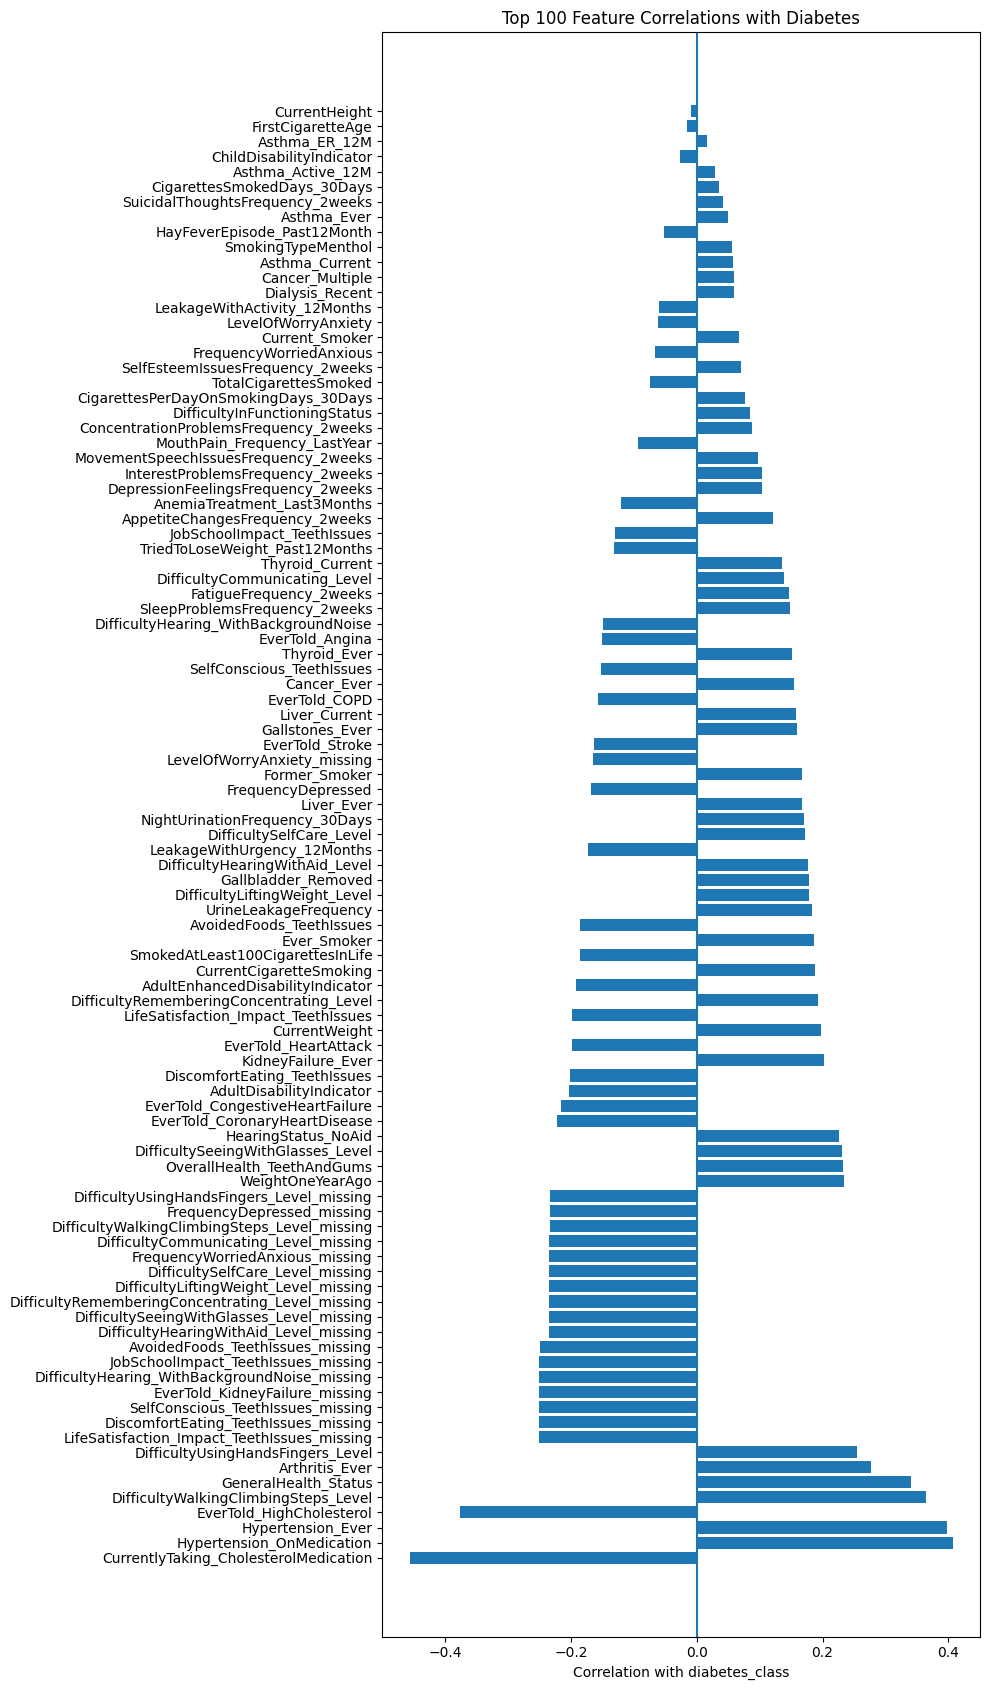

In [25]:
corr_series = pd.Series(sorted_correlations)
print(f"Number of features with correlations: {corr_series.size}")
TOP_N = 100
top_corr = corr_series.reindex(
    corr_series.abs().sort_values(ascending=False).head(TOP_N).index
)

MODEL_INPUT_FEATURES = list(top_corr.index)

def get_label(col):
    try:
        desc_info = desc(col)
        return desc_info['renamed']
    except:
        return col

labels = [get_label(col) for col in top_corr.index]
print("\nTop 100 Feature Correlations with Diabetes:\n")
for label, value in zip(labels, top_corr.values):
    print(f"{label}: {value:.4f}")
    

plt.figure(figsize=(10, 17))
plt.barh(labels, top_corr.values)
plt.axvline(0)  # zero reference
plt.xlabel('Correlation with diabetes_class')
plt.title(f'Top {TOP_N} Feature Correlations with Diabetes')
plt.tight_layout()
plt.show()


In [26]:
print(sorted(combined_with_target.isnull().sum()))
print(combined_with_target["diabetes_class"].count())
print(combined_with_target["diabetes_class"].value_counts())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3555, 3555, 6157, 6162, 6169, 6176, 7802, 10520]
10542
diabetes_class
0    9461
1    1081
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, f1_score, accuracy_score,
    classification_report, roc_auc_score, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

X = combined_with_target[MODEL_INPUT_FEATURES]
y = combined_with_target['diabetes_class']

positive_class = 1
target_names = ['No Diabetes (0)', 'Diabetes (1)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {}

# XGBoost
models['XGBoost'] = XGBClassifier(
    objective='binary:logistic',
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# LightGBM
models['LightGBM'] = LGBMClassifier(
    objective='binary',
    n_estimators=400,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# CatBoost
models['CatBoost'] = CatBoostClassifier(
    loss_function='Logloss',
    iterations=400,
    learning_rate=0.05,
    depth=7,
    random_seed=42,
    verbose=False
)

TARGET_RECALL = 0.85
results = []

for name, model in models.items():
    print(f"Training: {name}")

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    best_thr, best_diff = 0.5, np.inf
    for t in np.arange(0.05, 0.95, 0.05):
        y_tmp = (y_proba > t).astype(int)
        r = recall_score(y_test, y_tmp, pos_label=positive_class, zero_division=0)
        if abs(r - TARGET_RECALL) < best_diff:
            best_thr, best_diff = t, abs(r - TARGET_RECALL)
    y_pred = (y_proba > best_thr).astype(int)

    pos_recall = recall_score(y_test, y_pred, pos_label=positive_class, zero_division=0)
    pos_f1 = f1_score(y_test, y_pred, pos_label=positive_class, zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Threshold': best_thr,
        'Test_Acc': acc,
        'ROC_AUC': roc_auc,
        'Class_1_Recall': pos_recall,
        'Class_1_F1': pos_f1
    })

    print(f"\nOptimal Threshold: {best_thr:.2f}")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Class_1_Recall', ascending=False)
print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
display(results_df)


Training: XGBoost

Optimal Threshold: 0.05
                 precision    recall  f1-score   support

No Diabetes (0)      0.976     0.822     0.892      1893
   Diabetes (1)      0.346     0.824     0.487       216

       accuracy                          0.822      2109
      macro avg      0.661     0.823     0.690      2109
   weighted avg      0.912     0.822     0.851      2109

Training: LightGBM
[LightGBM] [Info] Number of positive: 865, number of negative: 7568
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 790
[LightGBM] [Info] Number of data points in the train set: 8433, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102573 -> initscore=-2.168955
[LightGBM] [Info] Start training from score -2.168955

Optimal Threshold: 0.05
               

,Model,Threshold,Test_Acc,ROC_AUC,Class_1_Recall,Class_1_F1
1,LightGBM,0.05,0.821242,0.897410,0.847222,0.492598
0,XGBoost,0.05,0.822191,0.899546,0.824074,0.487004
2,CatBoost,0.10,0.834045,0.906298,0.814815,0.501425


Classes: [0, 1]
ROC-AUC Score: 0.9079

MODEL REPORT
Optimal Threshold: 0.50
Test Accuracy: 0.8274
Class 1 Recall: 0.866
Class 1 F1: 0.507

Classification Report:

                 precision    recall  f1-score   support

No Diabetes (0)      0.982     0.823     0.895      1893
   Diabetes (1)      0.358     0.866     0.507       216

       accuracy                          0.827      2109
      macro avg      0.670     0.844     0.701      2109
   weighted avg      0.918     0.827     0.856      2109


Confusion Matrix (Counts):


,No Diabetes (0),Diabetes (1)
No Diabetes (0),1558,335
Diabetes (1),29,187



Confusion Matrix (% of True Class):


,No Diabetes (0),Diabetes (1)
No Diabetes (0),82.30,17.70
Diabetes (1),13.43,86.57


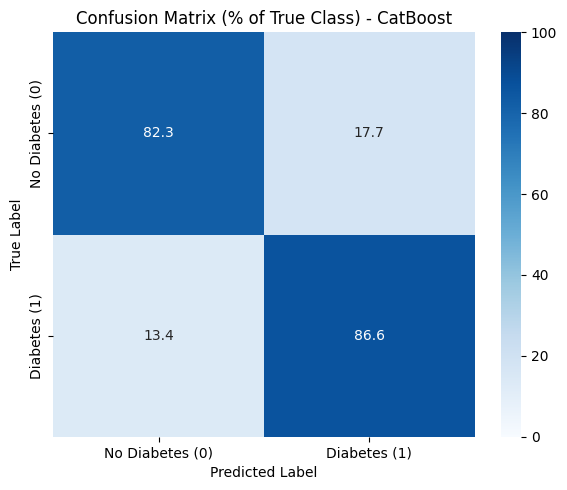

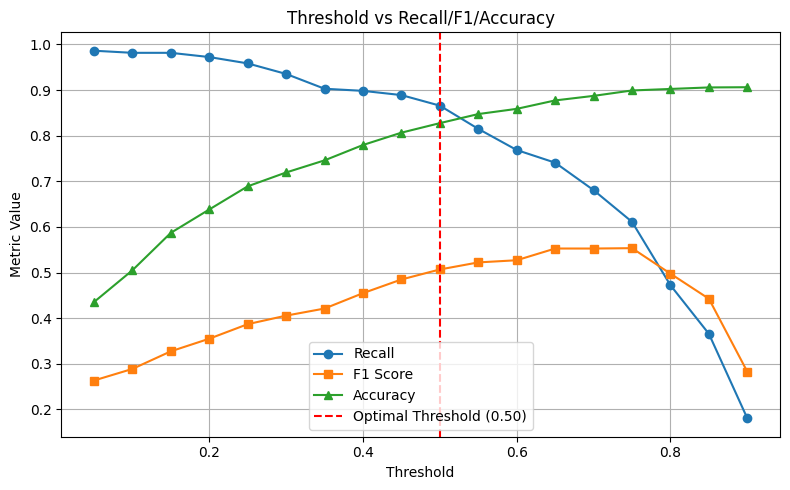

In [28]:
# from sklearn.metrics import (
#     recall_score, f1_score, accuracy_score,
#     classification_report, roc_auc_score, confusion_matrix
# )

X = combined_with_target[MODEL_INPUT_FEATURES]
y = combined_with_target['diabetes_class']

positive_class = 1
target_names = ['No Diabetes (0)', 'Diabetes (1)']

print("=" * 70)
print(f"Classes: [0, 1]")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weights = [1.0, neg / pos]

cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=4000,
    learning_rate=0.03,        # ⬅️ stronger gradients
    depth=7,                   # ⬅️ moderate complexity
    l2_leaf_reg=3,             # ⬅️ tighter leaves = sharper probs
    min_data_in_leaf=40,
    random_strength=1.0,
    bagging_temperature=0.5,   # ⬅️ reduce noise
    colsample_bylevel=0.8,
    boosting_type="Ordered",
    nan_mode="Min",
    class_weights=[1.0, neg / pos],  # ⬅️ KEEP real imbalance
    random_seed=42,
    verbose=False
)


cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=1000,
    use_best_model=True
)

# from sklearn.calibration import CalibratedClassifierCV

# calibrated_cat = CalibratedClassifierCV(
#     estimator=cat,
#     method="isotonic",   # best for tree models
#     cv=5
# )

# calibrated_cat.fit(X_train, y_train)


y_proba = cat.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

thresholds = np.arange(0.05, 0.95, 0.05)
recalls, f1s, accs = [], [], []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t, pos_label=positive_class))
    f1s.append(f1_score(y_test, y_pred_t, pos_label=positive_class))
    accs.append(accuracy_score(y_test, y_pred_t))

TARGET_RECALL = 0.875
best_idx = np.argmin(np.abs(np.array(recalls) - TARGET_RECALL))
best_thr = thresholds[best_idx]
y_pred = (y_proba > best_thr).astype(int)


pos_recall = recalls[best_idx]
pos_f1 = f1s[best_idx]
acc = accs[best_idx]

print("\n" + "=" * 70)
print("MODEL REPORT")
print("=" * 70)
print(f"Optimal Threshold: {best_thr:.2f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Class 1 Recall: {pos_recall:.3f}")
print(f"Class 1 F1: {pos_f1:.3f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))


cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_pct_df = pd.DataFrame(cm_pct, index=target_names, columns=target_names)

print("\nConfusion Matrix (Counts):")
display(cm_df)
print("\nConfusion Matrix (% of True Class):")
display(cm_pct_df.round(2))

plt.figure(figsize=(6,5))
sns.heatmap(cm_pct_df, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100)
plt.title("Confusion Matrix (% of True Class) - CatBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, f1s, marker='s', label='F1 Score')
plt.plot(thresholds, accs, marker='^', label='Accuracy')
plt.axvline(best_thr, color='red', linestyle='--', label=f'Optimal Threshold ({best_thr:.2f})')
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold vs Recall/F1/Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


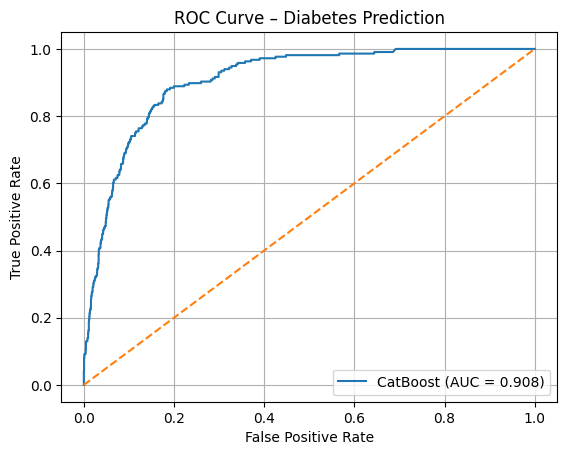

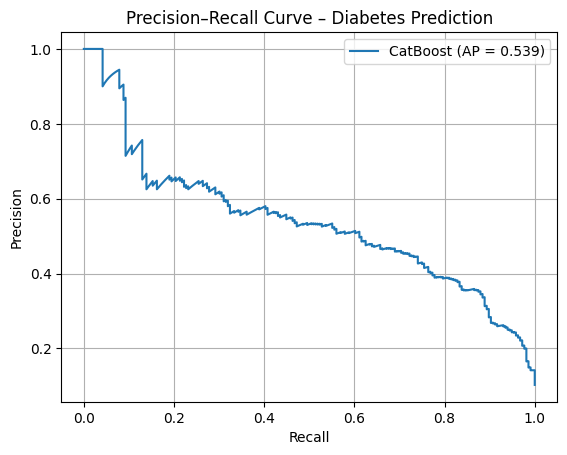

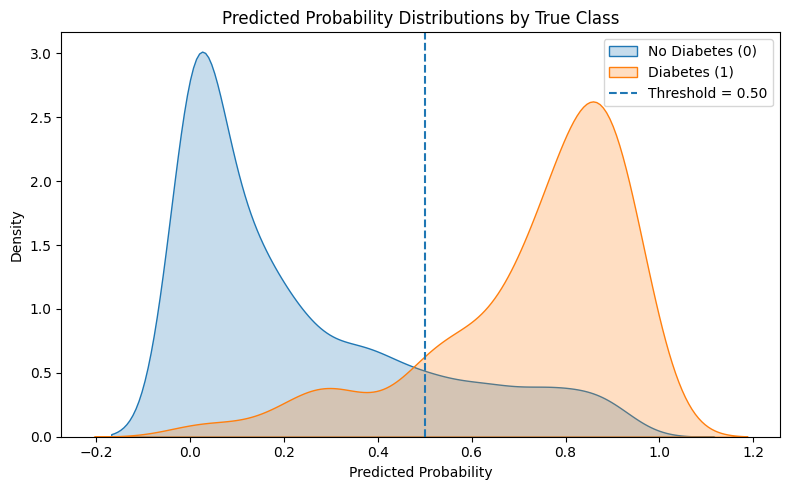

In [29]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_score = y_proba  # Probability for Diabetes (Class 1)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Diabetes Prediction')
plt.legend()
plt.grid(True)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)

plt.figure()
plt.plot(recall, precision, label=f'CatBoost (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve – Diabetes Prediction')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
sns.kdeplot(y_proba[y_test == 0], label="No Diabetes (0)", fill=True)
sns.kdeplot(y_proba[y_test == 1], label="Diabetes (1)", fill=True)
plt.axvline(best_thr, linestyle="--", label=f"Threshold = {best_thr:.2f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distributions by True Class")
plt.legend()
plt.tight_layout()
plt.show()


Top 50 Important Features:



,Feature_Code,Feature_Name,Importance
0,BPQ101D,CurrentlyTaking_CholesterolMedication,16.461424
5,HUQ010,GeneralHealth_Status,13.497701
2,Hypertension_Ever,Hypertension_Ever,7.877925
4,FNQ440,DifficultyWalkingClimbingSteps_Level,6.109967
25,WHD050,WeightOneYearAgo,5.282535
...,...,...,...
54,MCQ160F,EverTold_Stroke,0.000000
40,SMQ020,SmokedAtLeast100CigarettesInLife,0.000000
67,WHQ070,TriedToLoseWeight_Past12Months,0.000000
86,Asthma_Current,Asthma_Current,0.000000


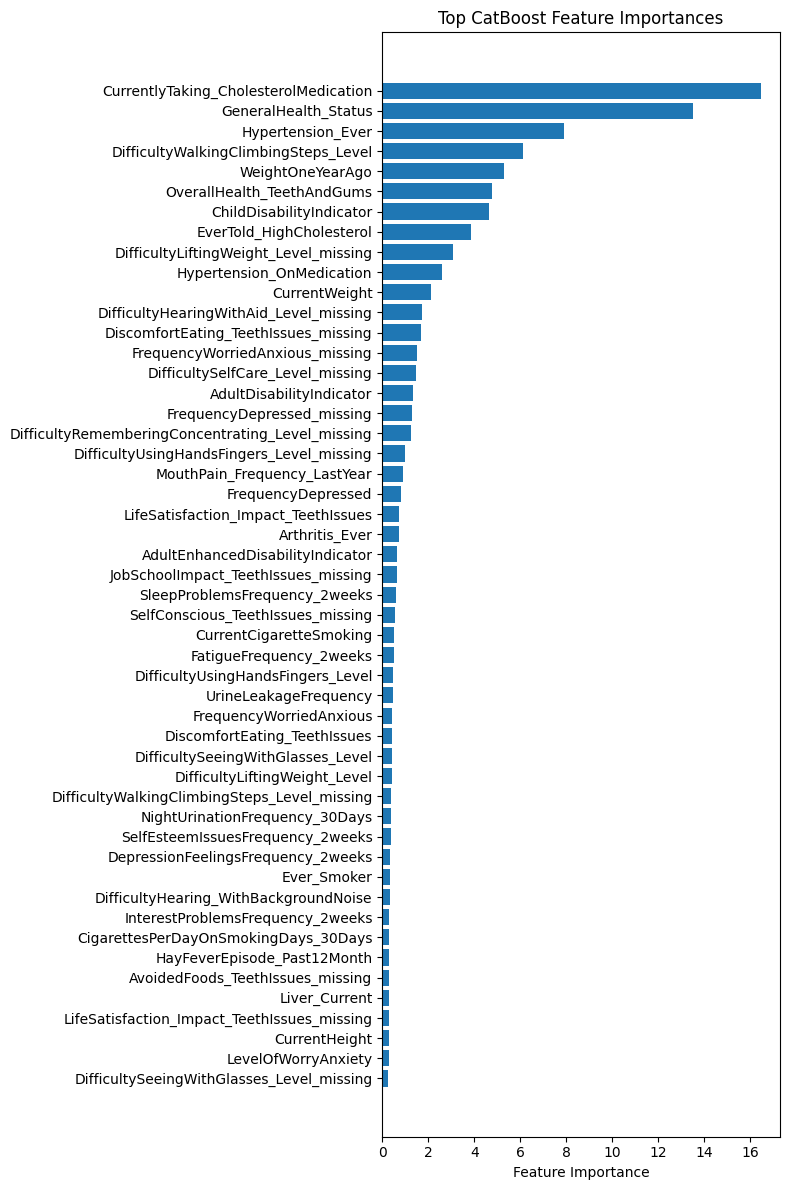

In [30]:

from catboost import Pool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_pool = Pool(X_train, label=y_train)

importances = cat.get_feature_importance(
    data=train_pool,
    type='FeatureImportance'
)

feature_names = [desc(c)['renamed'] for c in X_train.columns]


feat_df = pd.DataFrame({
    'Feature_Code': X_train.columns,
    'Feature_Name': feature_names,
    'Importance': importances
})

feat_df = feat_df.sort_values('Importance', ascending=False)

print("\nTop 50 Important Features:\n")
display(feat_df.head(100))


TOP_K = 50
plot_df = feat_df.head(TOP_K).iloc[::-1]  

plt.figure(figsize=(8, 12))
plt.barh(plot_df['Feature_Name'], plot_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Top CatBoost Feature Importances')
plt.tight_layout()
plt.show()


In [ ]:
combined_with_target["BMI"] = combined_with_target["WHD020"] / (combined_with_target["WHD010"] / 100) ** 2
combined_with_target["WeightChange"] = combined_with_target["WHD020"] - combined_with_target["WHD050"]
combined_with_target["FunctionalScore"] = (
    combined_with_target["FNQ440"] +
    combined_with_target["FNQ480"] +
    combined_with_target["FNQ470"]
)


feat_set = set(feat_df['Feature_Code'].tolist())
REFINED_INPUT_FEATURES = [

        # --- Cardiometabolic / Medical History ---
        "BPQ080",      # Ever told you had high cholesterol
        "BPQ101D",     # Currently taking cholesterol medication
        "Hypertension_Ever",
        "Hypertension_OnMedication",
        "MCQ160C",     # Ever told had coronary heart disease

        # --- Weight & Body ---
        "WHD020",      # Current weight
        "WHD050",      # Weight one year ago
        "WHD010",      # Height
        "WHQ070",      # Tried to lose weight in past 12 months

        # --- General Health ---
        "HUQ010",      # Self-reported general health

        # --- Functional Limitations (REAL VALUES ONLY) ---
        "FNQ440",      # Difficulty walking/climbing steps
        "FNQ480",      # Difficulty lifting/carrying
        "FNQ460",      # Difficulty remembering/concentrating
        "FNQ470",      # Difficulty with self-care
        "FNQ490",      # Difficulty using hands/fingers

        # # --- Disability (compressed to ONE indicator) ---
        "FNDAEDI",     # Adult enhanced disability indicator

        # --- Mental Health (core metabolic signals) ---
        "DPQ020",      # Depressed mood frequency (2 weeks)
        "DPQ030",      # Sleep problems frequency
        "DPQ040",      # Fatigue frequency
        "DPQ050",      # Appetite changes frequency

        # --- Medical Condition ---
        "KidneyFailure_Ever",
        "Liver_Ever",
        "Arthritis_Ever",
        "Asthma_Ever",
        "Dialysis_Recent",
        "Thyroid_Current",
        "Gallstones_Ever",

        # --- Smoking ---
        "Ever_Smoker",
        "Current_Smoker",
        "Former_Smoker",
        "SMD650",      # Cigarettes per day (recent)

        # --- Engineered Features ---
        "BMI",
        "WeightChange",
        "FunctionalScore"
    ]
# Convert to sets
feat_set = set(feat_df['Feature_Code'].dropna())
refined_features = set(REFINED_INPUT_FEATURES)

# Features NOT used in refined input
missing_in_refined = feat_set - refined_features

print("\nFeatures in feat_df but NOT in REFINED_INPUT_FEATURES:\n")

for feat in sorted(missing_in_refined):
    try:
        print(f"- {feat} ({desc(feat)['renamed']})")
    except Exception:
        print(f"- {feat} (no description available)")



Features in feat_df but NOT in REFINED_INPUT_FEATURES:

- AGQ030 (HayFeverEpisode_Past12Month)
- AUQ054 (HearingStatus_NoAid)
- AUQ101 (DifficultyHearing_WithBackgroundNoise)
- AUQ101_missing (DifficultyHearing_WithBackgroundNoise_missing)
- Asthma_Active_12M (Asthma_Active_12M)
- Asthma_Current (Asthma_Current)
- Asthma_ER_12M (Asthma_ER_12M)
- Cancer_Ever (Cancer_Ever)
- Cancer_Multiple (Cancer_Multiple)
- DPQ010 (InterestProblemsFrequency_2weeks)
- DPQ060 (SelfEsteemIssuesFrequency_2weeks)
- DPQ070 (ConcentrationProblemsFrequency_2weeks)
- DPQ080 (MovementSpeechIssuesFrequency_2weeks)
- DPQ090 (SuicidalThoughtsFrequency_2weeks)
- DPQ100 (DifficultyInFunctioningStatus)
- FNDADI (AdultDisabilityIndicator)
- FNDCDI (ChildDisabilityIndicator)
- FNQ410 (DifficultySeeingWithGlasses_Level)
- FNQ410_missing (DifficultySeeingWithGlasses_Level_missing)
- FNQ430 (DifficultyHearingWithAid_Level)
- FNQ430_missing (DifficultyHearingWithAid_Level_missing)
- FNQ440_missing (DifficultyWalkingClimbi

ROC-AUC: 0.9074

FINAL REPORT 
Optimal Threshold: 0.497
Recall (Class 1): 0.875
F1 (Class 1): 0.503
Accuracy: 0.823

                 precision    recall  f1-score   support

No Diabetes (0)      0.983     0.817     0.892      1893
   Diabetes (1)      0.353     0.875     0.503       216

       accuracy                          0.823      2109
      macro avg      0.668     0.846     0.698      2109
   weighted avg      0.918     0.823     0.853      2109



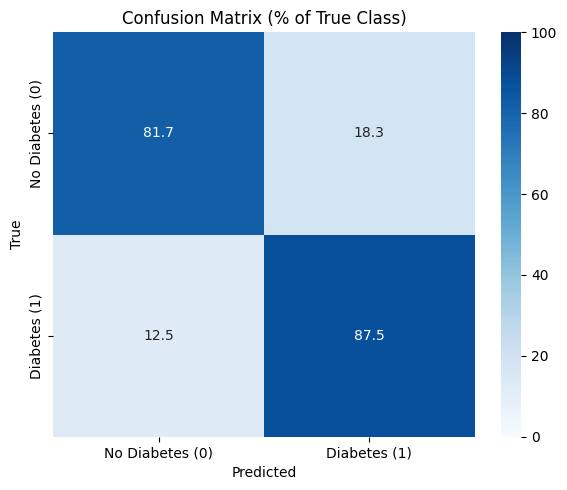

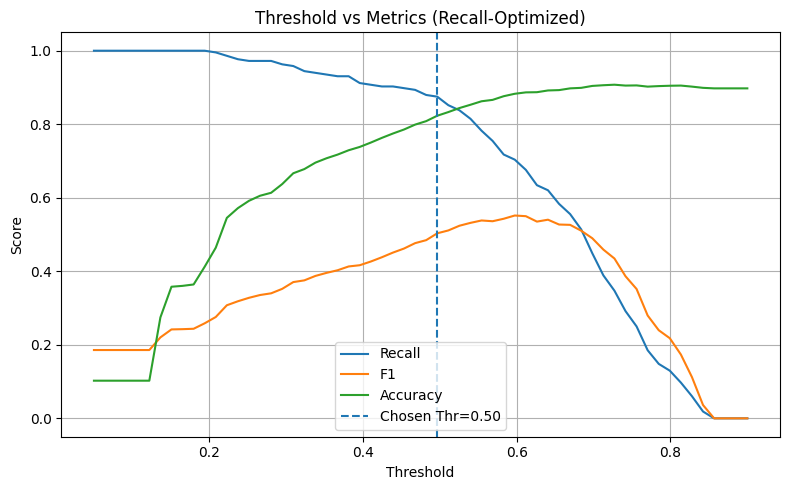

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, f1_score, accuracy_score,
    classification_report, roc_auc_score,
    confusion_matrix
)

from catboost import CatBoostClassifier

X = combined_with_target[REFINED_INPUT_FEATURES]
y = combined_with_target["diabetes_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from sklearn.utils import resample

Xy = pd.concat([X_train, y_train], axis=1)

majority = Xy[Xy.diabetes_class == 0]
minority = Xy[Xy.diabetes_class == 1]

majority_down = resample(
    majority,
    replace=False,
    n_samples=len(minority),  # keep some imbalance
    random_state=42
)

balanced = pd.concat([majority_down, minority])

X_train = balanced[REFINED_INPUT_FEATURES]
y_train = balanced["diabetes_class"]

target_names = ["No Diabetes (0)", "Diabetes (1)"]
positive_class = 1

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

class_weights = [1.0, neg / pos]

cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=4000,
    learning_rate=0.03,        # ⬅️ stronger gradients
    depth=7,                   # ⬅️ moderate complexity
    l2_leaf_reg=3,             # ⬅️ tighter leaves = sharper probs
    min_data_in_leaf=40,
    random_strength=1.0,
    bagging_temperature=0.5,   # ⬅️ reduce noise
    colsample_bylevel=0.8,
    boosting_type="Ordered",
    nan_mode="Min",
    class_weights=[1.0, neg / pos],  # ⬅️ KEEP real imbalance
    random_seed=42,
    verbose=False
)


cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=1000,
    use_best_model=True
)
from sklearn.calibration import CalibratedClassifierCV

# calibrated_cat = CalibratedClassifierCV(
#     estimator=cat,
#     method="isotonic",   # best for tree models
#     cv=5
# )

# calibrated_cat.fit(X_train, y_train)


y_proba = cat.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

thresholds = np.linspace(0.05, 0.90, 60)

results = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    results.append({
        "thr": t,
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "acc": accuracy_score(y_test, y_pred)
    })

res = pd.DataFrame(results)

TARGET_RECALL = 0.87

eligible = res[res["recall"] >= TARGET_RECALL]
best_row = eligible.sort_values("f1", ascending=False).iloc[0]

best_thr = best_row["thr"]

y_pred = (y_proba >= best_thr).astype(int)

print("\n" + "=" * 70)
print("FINAL REPORT ")
print("=" * 70)
print(f"Optimal Threshold: {best_thr:.3f}")
print(f"Recall (Class 1): {best_row['recall']:.3f}")
print(f"F1 (Class 1): {best_row['f1']:.3f}")
print(f"Accuracy: {best_row['acc']:.3f}\n")

print(classification_report(
    y_test, y_pred,
    target_names=target_names,
    digits=3
))

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm/ cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix (% of True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(res["thr"], res["recall"], label="Recall")
plt.plot(res["thr"], res["f1"], label="F1")
plt.plot(res["thr"], res["acc"], label="Accuracy")
plt.axvline(best_thr, linestyle="--", label=f"Chosen Thr={best_thr:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics (Recall-Optimized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


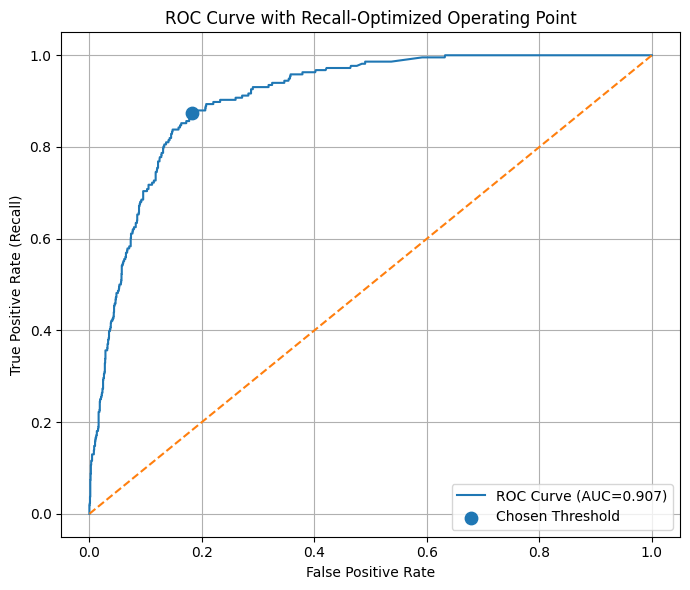

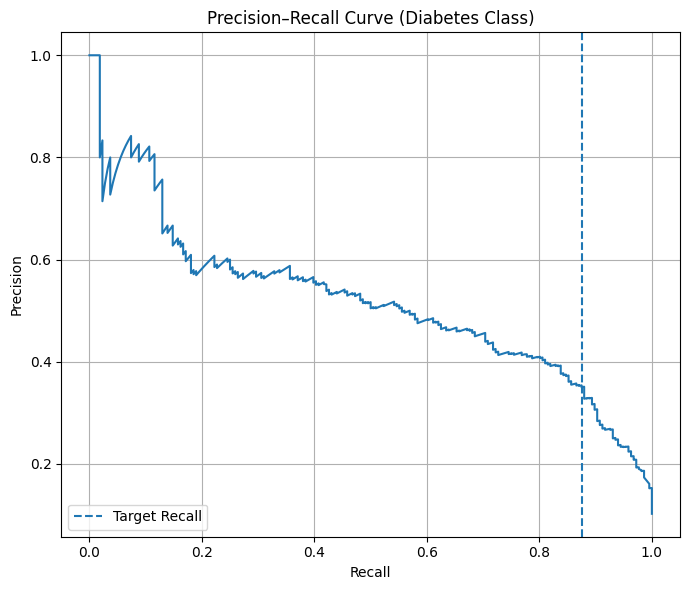

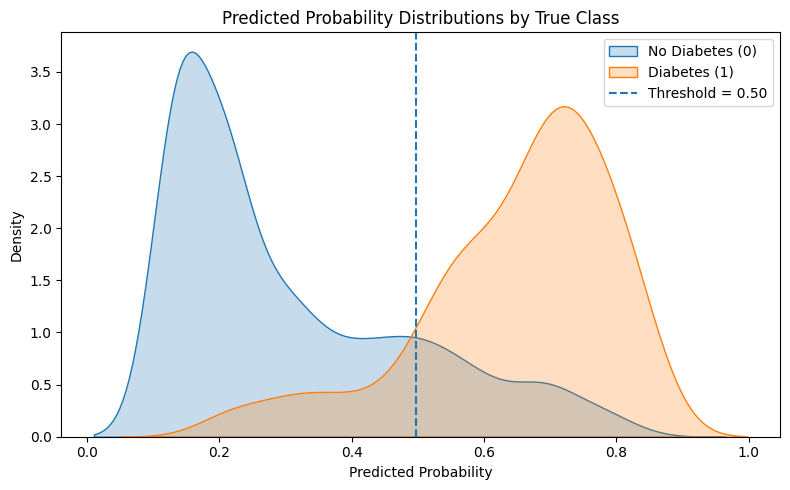

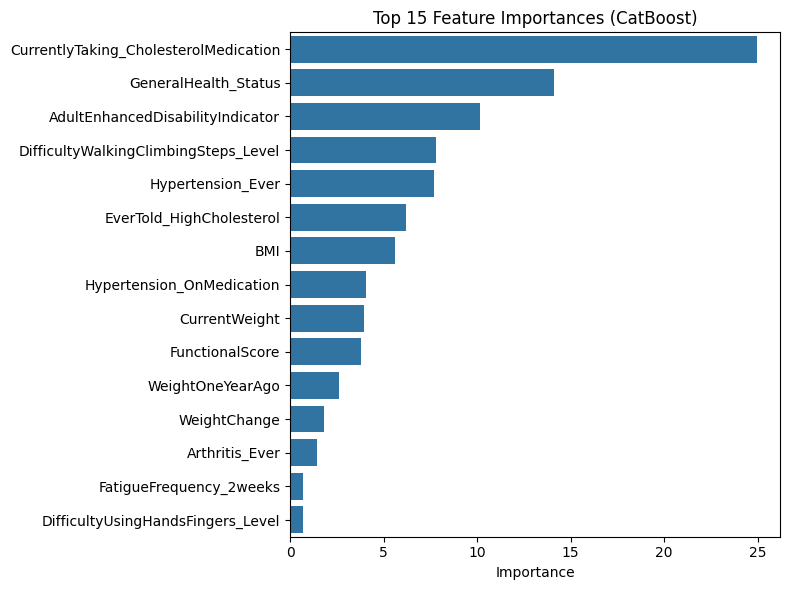

In [38]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

# find closest ROC threshold to chosen best_thr
idx = np.argmin(np.abs(roc_thresholds - best_thr))

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc:.3f})")
plt.scatter(fpr[idx], tpr[idx], s=80, marker="o", label="Chosen Threshold")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Recall-Optimized Operating Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision)
plt.axvline(best_row["recall"], linestyle="--", label="Target Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Diabetes Class)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(y_proba[y_test == 0], label="No Diabetes (0)", fill=True)
sns.kdeplot(y_proba[y_test == 1], label="Diabetes (1)", fill=True)
plt.axvline(best_thr, linestyle="--", label=f"Threshold = {best_thr:.2f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distributions by True Class")
plt.legend()
plt.tight_layout()
plt.show()

importances = cat.get_feature_importance()
featuress = [desc(f)['renamed'] for f in REFINED_INPUT_FEATURES]
feat_imp = (
    pd.DataFrame({
        "feature": featuress,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp,
    y="feature",
    x="importance"
)
plt.title("Top 15 Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

